In [546]:
import sys
sys.path.append('/Users/isaac/Documents/MASS/Academic/2nd semester/AGN/tutorials/AGN-tutorials/SciScript-Python')

from SciServer import Authentication, CasJobs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, FancyArrowPatch
plt.style.use('seaborn-v0_8-deep')
plt.rcParams.update({'font.size': 12})

# Task 1

a) Obtain the objects and make a BPT diagram

In [ ]:
Authentication.login('', '')

# We are running the query with the WISE cross-match from the start to be used later
query = '''
    SELECT TOP 10000
        s.specobjid,s.z,
        g.oiii_5007_flux,
        g.oi_6300_flux,
        g.h_beta_flux,
        g.h_alpha_flux,
        g.h_alpha_eqw,
        g.sii_6717_flux,
        g.sii_6731_flux,
        g.nii_6584_flux,
        g.oiii_5007_flux / g.h_beta_flux   AS oiii_hbeta_ratio,
        g.nii_6584_flux  / g.h_alpha_flux  AS nii_halpha_ratio,
        w.w1mpro AS w1,
        w.w2mpro AS w2,
        w.w3mpro AS w3,
        w.w1mpro - w.w2mpro AS w1_w2,
        w.w2mpro - w.w3mpro AS w2_w3

    FROM SpecObj AS s
        JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
        JOIN photoTag AS p ON s.bestobjid = p.objid
        JOIN wise_xmatch AS x ON p.objid = x.sdss_objid
        JOIN wise_allsky AS w ON x.wise_cntr = w.cntr

    WHERE
        s.class      = 'GALAXY' AND
        s.z          < 0.35     AND
        s.snmedian_g > 20       AND

        -- Velocity dispersion (FWHM < 500 km/s)
        2.3548 * g.sigma_balmer < 500 AND
        2.3548 * g.oiii_sigma   < 500 AND

        -- Emission line detection (negative EQW = emission)
        g.oiii_5007_eqw  < -0.1 AND
        g.oi_6300_eqw    < -0.1 AND
        g.h_beta_eqw     < -0.1 AND
        g.h_alpha_eqw    < -0.1 AND
        g.nii_6584_eqw   < -0.1 AND
        g.sii_6717_eqw   < -0.1 AND
        g.sii_6731_eqw   < -0.1 AND

        -- Minimum absolute flux
        g.oiii_5007_flux > 5 AND
        g.oi_6300_flux   > 5 AND
        g.h_beta_flux    > 5 AND
        g.h_alpha_flux   > 5 AND
        g.nii_6584_flux  > 5 AND
        g.sii_6717_flux  > 5 AND
        g.sii_6731_flux  > 5 AND

        -- flux > 5 * flux_err for all diagnostic lines
        g.oiii_5007_flux > 5 * g.oiii_5007_flux_err AND
        g.oi_6300_flux   > 5 * g.oi_6300_flux_err   AND
        g.h_beta_flux    > 5 * g.h_beta_flux_err     AND
        g.h_alpha_flux   > 5 * g.h_alpha_flux_err    AND
        g.nii_6584_flux  > 5 * g.nii_6584_flux_err  AND
        g.sii_6717_flux  > 5 * g.sii_6717_flux_err  AND
        g.sii_6731_flux  > 5 * g.sii_6731_flux_err
'''

result = CasJobs.executeQuery(query, context='DR18')
result.to_csv('agn_sample.csv', index=False)

In [74]:
len(result)

10000

In [75]:
result.head()

,specobjid,z,oiii_5007_flux,oi_6300_flux,h_beta_flux,h_alpha_flux,h_alpha_eqw,sii_6717_flux,sii_6731_flux,nii_6584_flux,oiii_hbeta_ratio,nii_halpha_ratio,w1,w2,w3,w1_w2,w2_w3
0,413295734146754560,0.125732,26.67162,10.99707,108.7524,524.4837,-26.807350,63.39495,47.30184,186.4741,0.245251,0.355538,13.254,12.922,8.785,0.332000,4.137
1,413269895623501824,0.061882,78.43416,23.49678,115.0233,612.8790,-14.271790,89.12791,82.71341,497.0024,0.681898,0.810931,12.569,12.397,8.770,0.172000,3.627
2,700432097185130496,0.043296,3937.53000,92.88883,1305.9210,4881.6750,-268.383000,460.71040,345.78500,465.8369,3.015137,0.095426,14.175,13.566,9.029,0.609000,4.537
3,549597516325218304,0.010970,91.87317,25.85766,124.5139,532.1008,-5.441545,140.68830,112.16530,387.5037,0.737855,0.728252,10.937,10.966,7.920,-0.028999,3.046
4,550578830721443840,0.005577,1510.62000,117.82380,910.3036,3310.6090,-26.574260,366.12410,357.68970,882.5734,1.659468,0.266589,11.635,11.495,7.527,0.140000,3.968


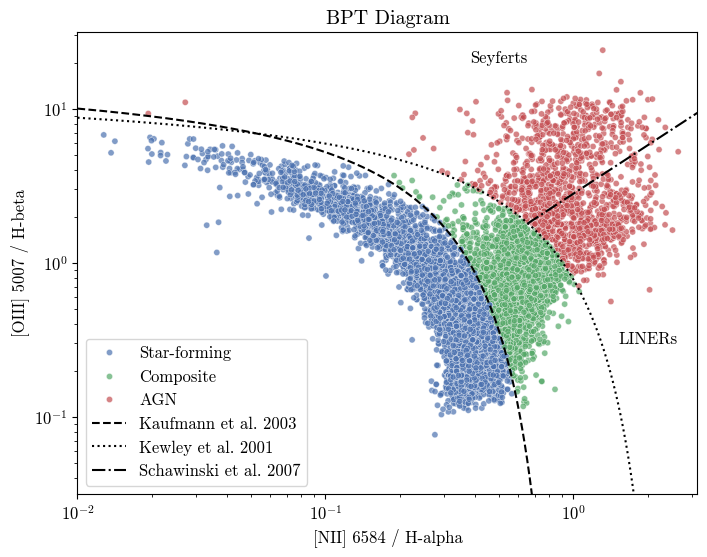

In [551]:
x = np.logspace(-2,0.5,500)
x_kauf = x[x<10**0.05]
x_kew = x[x<10**0.47]
x_schaw = x[x>0.65]

def kauffmann(log_nii_halpha):
    return 0.61 / (log_nii_halpha - 0.05) + 1.3

def kewley(log_nii_halpha):
    return 0.61 / (log_nii_halpha - 0.47) + 1.19

def schawinski(log_nii_halpha):
    return 1.05 * log_nii_halpha + 0.45

# Classification
log_nii = np.log10(result['nii_halpha_ratio'])
log_oiii = np.log10(result['oiii_hbeta_ratio'])
below_kauffmann = (log_nii < 0.05) & (log_oiii < kauffmann(log_nii))
above_kewley    = (log_nii < 0.47) & (log_oiii > kewley(log_nii)) | (log_nii >= 0.47)
above_schawinski = (log_nii > -0.05) & (log_oiii > schawinski(log_nii))

sf        = below_kauffmann
agn       = above_kewley & ~sf
composite = ~sf & ~agn

result['BPT_class'] = 'Unclassified'
result.loc[sf, 'BPT_class'] = 'Star-forming'
result.loc[agn, 'BPT_class'] = 'AGN'
result.loc[composite, 'BPT_class'] = 'Composite'
#result.loc[above_schawinski, 'BPT_class'] = 'Seyfert'
#result.loc[above_kewley & ~above_schawinski, 'BPT_class'] = 'LINER'

plt.figure(figsize=(8,6))
# Data points
sns.scatterplot(result,x='nii_halpha_ratio',y='oiii_hbeta_ratio',hue='BPT_class',s=20,alpha=0.7)

# Classification lines
plt.plot(x_kauf,10**(0.61/(np.log10(x_kauf)-0.05)+1.3), color='k', linestyle='--', label='Kaufmann et al. 2003')
plt.plot(x_kew,10**(0.61/(np.log10(x_kew)-0.47)+1.19), color='k', linestyle=':', label='Kewley et al. 2001')
plt.plot(x_schaw,10**(1.05*np.log10(x_schaw)+0.45), color='k', linestyle='-.', label='Schawinski et al. 2007')

# Text labels
plt.text(2,0.3,'LINERs', fontsize=12, ha='center')
plt.text(0.5,20,'Seyferts', fontsize=12, ha='center')

# Plot settings
plt.xscale('log')
plt.yscale('log')
plt.xlabel('[NII] 6584 / H-alpha')
plt.ylabel('[OIII] 5007 / H-beta')
plt.xlim(10**-2, 10**0.5)
plt.ylim(10**-1.5, 10**1.5)
plt.title('BPT Diagram')
plt.legend()
plt.show()

b) Make a WHAN diagram

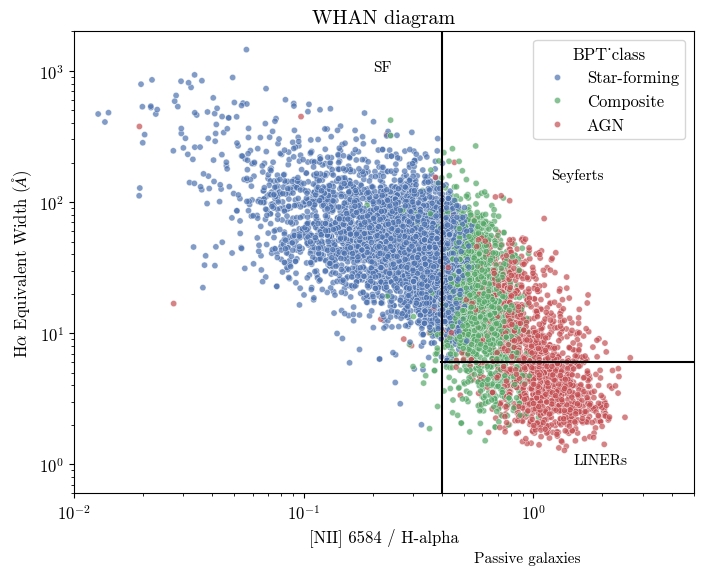

In [552]:
plt.figure(figsize=(8,6))
result['abs_h_alpha_eqw'] = np.abs(result['h_alpha_eqw'])
sns.scatterplot(result,y='abs_h_alpha_eqw',x='nii_halpha_ratio',hue='BPT_class',s=20,alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'H$\alpha$ Equivalent Width $(\AA)$')
plt.xlabel('[NII] 6584 / H-alpha')
plt.xlim(0.01, 5)
plt.ylim(0.6, 2e3)

# Classification lines
plt.axvline(x=0.4, color='k')
plt.axhline(y=6,xmin=0.593,xmax=1, color='k') # Seyfert vs LINER
#plt.axhline(y=0.5, xmax=0.59,color='k', linestyle='--', linewidth=1.2)
#plt.axhline(y=0.5, xmin=0.59,color='k', linestyle=':', linewidth=1.2)

# Diagonal line
#xx = np.logspace(np.log10(0.1), np.log10(5), 500)   # linear-space values for log-axis plot
#yy = 0.5 / xx
#plt.plot(xx[xx<1], yy[xx<1], color='k', linestyle=':', linewidth=1.2)
#plt.plot(xx[xx>=1], yy[xx>=1], color='k', linestyle='--', linewidth=1.2)

# Region labels
plt.text(0.2,  1000, 'SF', fontsize=11)
plt.text(1.2,  150, 'Seyferts', fontsize=11)
plt.text(1.5,  1, 'LINERs', fontsize=11)
plt.text(0.55,  0.18, 'Passive galaxies',fontsize=11)

plt.title('WHAN diagram')
plt.show()

In [556]:
# Count objects classified as Seyfert in WHAN diagram that also are AGN in BPT diagram
seyfert_whan = (result['nii_halpha_ratio'] > 0.4)
both_seyfert = seyfert_whan & (result['BPT_class'] == 'AGN')

print('Objects classified as Seyfert in WHAN and BPT diagram:\n'
      f'Number: {both_seyfert.sum()}\n'
      f'Percentage: {both_seyfert.sum() / len(result) * 100:.2f}%')

Objects classified as Seyfert in WHAN and BPT diagram:
Number: 1377
Percentage: 13.77%


# Task 2

In [557]:
# --- Colors from the query output ---
x = result['w2_w3']   # W2 - W3 [Vega mag]
y = result['w1_w2']   # W1 - W2 [Vega mag]

# --- Mateos+2012 wedge boundaries (converted to magnitude space) ---

def top_boundary(x):    return  0.315 * x + 0.796
def bottom_boundary(x): return  0.315 * x - 0.220
def powerlaw_limit(x):  return -3.172 * x + 7.624

# --- Wedge selection mask --- #
in_wedge = (
    (y <  top_boundary(x))    &   # below top line
    (y >  bottom_boundary(x)) &   # above bottom line
    (y >  powerlaw_limit(x))      # above power-law bottom-left limit
)

print("Objects inside Mateos wedge:\n"
      f'Number: {in_wedge.sum()}\n'
      f'Percentage: {in_wedge.sum() / len(result) * 100:.2f}%')

Objects inside Mateos wedge:
Number: 86
Percentage: 0.86%


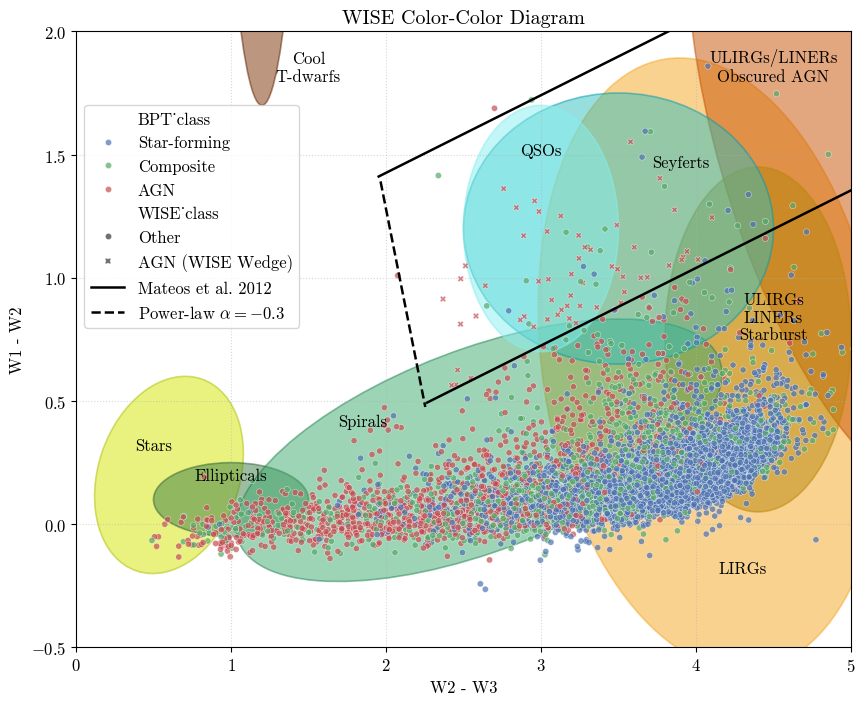

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlim(0, 5)
ax.set_ylim(-0.5,2)

# Wright et al 2010 Fig.12 blobs
# Each tuple: (center_x, center_y, width, height, angle_deg, facecolor, edgecolor, label)
blobs = [
    # LIRGs
    (4.1, 0.65, 2.6, 2.1, 120, "#F5A623", "#F5A623", 'LIRGs'),
    # ULIRGs / LINERs / Obscured AGN
    (5.0, 1.55, 3.2, 1.6, 120, "#C85000", "#C85000", 'ULIRGs/LINERs Obscured AGN'),
    # ULIRGs / LINERs / Starburst 
    (4.4, 0.75, 1.2, 1.4, 0,   "#B8860B", "#B8860B", 'ULIRGs/LINERs Starburst'),
    # Cool T-dwarfs
    (1.2, 4, 0.55, 4.6, 0,     '#7B2E00', '#5A2000', 'Cool T-dwarfs'),
    # Stars 
    (0.60, 0.20, 1, 0.75, 25,  '#D4E600', '#AABF00', 'Stars'),
    # Ellipticals
    (1, 0.10, 1, 0.3, 0,       "#3A7D44", '#2A5F32', 'Ellipticals'),
    # Spirals
    (2.6, 0.3, 3.2, 0.85, 12,  '#3DAA6E', '#1E8050', 'Spirals'),
    # Seyferts
    (3.5, 1.2, 2, 1.1, 0,      '#30BFBF', '#0099AA', 'Seyferts'),
    # QSOs
    (3, 1.2, 1, 1, 5,           "#88EEEE", "#88EEEE", 'QSOs'),
]

for cx, cy, w, h, ang, fc, ec, lbl in blobs:
    e = Ellipse((cx, cy), width=w, height=h, angle=ang,
                facecolor=fc, edgecolor=ec, alpha=0.5, linewidth=1.2, zorder=1)
    ax.add_patch(e)

ax.text(1.5, 1.8, 'Cool\nT-dwarfs', color='k',ha='center')
ax.text(0.50, 0.30, 'Stars', color='k', ha='center')
ax.text(1.85, 0.4, 'Spirals', color='k', ha='center')
ax.text(1.0, 0.18, 'Ellipticals', color='k', ha='center')
ax.text(3.90, 1.45, 'Seyferts',color='k', ha='center')
ax.text(3.0, 1.5, 'QSOs', color='k', ha='center')
ax.text(4.5, 1.8, 'ULIRGs/LINERs\nObscured AGN',color='k', ha='center')
ax.text(4.5, 0.75, 'ULIRGs\nLINERs\nStarburst',color='k', ha='center')
ax.text(4.30, -0.20, 'LIRGs', color='k', ha='center')

# Add special marker for objects inside the Mateos wedge and marked as AGN in BPT
wedge_agn = in_wedge & (result['BPT_class'] == 'AGN')

result['WISE_class'] = 'Other'
result.loc[wedge_agn, 'WISE_class'] = 'AGN (WISE Wedge)'

# Objects from our sample with BPT classification
sns.scatterplot(data=result, x='w2_w3', y='w1_w2',hue='BPT_class',style='WISE_class', s=20,alpha=0.7)

# Matteos et al 2012 Wedge boundaries
x_range = np.linspace(-0.5, 5.5, 500)
ax.plot(x_range[x_range>1.95], top_boundary(x_range[x_range>1.95]),    'k',  lw=1.8, label='Mateos et al. 2012')
ax.plot(x_range[x_range>2.26], bottom_boundary(x_range[x_range>2.26]), 'k', lw=1.8)
ax.plot(x_range[(x_range>1.96) & (x_range<2.26)], powerlaw_limit(x_range[(x_range>1.96) & (x_range<2.26)]),  'k--',  lw=1.8, label=r'Power-law $\alpha = -0.3$')

# Plot settings
ax.set_ylabel('W1 - W2')
ax.set_xlabel('W2 - W3')
ax.set_title('WISE Color-Color Diagram')
plt.legend(loc='center left', bbox_to_anchor=(0, 0.7))
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [558]:
print("Objects inside Mateos wedge that are also AGN in BPT diagram:\n"
      f'Number: {wedge_agn.sum()}\n'
      f'Percentage: {wedge_agn.sum() / len(result) * 100:.2f}%')

Objects inside Mateos wedge that are also AGN in BPT diagram:
Number: 56
Percentage: 0.56%


# Task 3